In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

from scipy.cluster.hierarchy import linkage, dendrogram, fcluster, cophenet
from scipy.spatial.distance import pdist

In [5]:
df = pd.read_csv("gene.csv")
print(df.head(3))
print(df.isnull().sum())
print(df.duplicated().sum())

      time     40    50     60    70    80    90   100   110   120  ...   170  \
0  YAL001C -0.070 -0.23 -0.100  0.03 -0.04 -0.12 -0.28 -0.44 -0.09  ...  0.59   
1  YAL014C  0.215  0.09  0.025 -0.04 -0.04 -0.02 -0.51 -0.08  0.00  ... -0.30   
2  YAL016W  0.150  0.15  0.220  0.29 -0.10  0.15 -0.73  0.19 -0.15  ...  0.12   

    180   190   200   210   220   230   240   250    260  
0  0.34 -0.28 -0.09 -0.44  0.31  0.03  0.57  0.00  0.010  
1 -0.38  0.07 -0.04  0.13 -0.06 -0.26 -0.10  0.27  0.235  
2 -0.17  0.11 -0.15  0.03 -0.26 -0.34 -0.34  0.25  0.190  

[3 rows x 24 columns]
time    0
40      0
50      0
60      0
70      0
80      0
90      0
100     0
110     0
120     0
130     0
140     0
150     0
160     0
170     0
180     0
190     0
200     0
210     0
220     0
230     0
240     0
250     0
260     0
dtype: int64
0


In [27]:
print(df.shape)
df.info()
df.describe()

(4381, 24)
<class 'pandas.DataFrame'>
RangeIndex: 4381 entries, 0 to 4380
Data columns (total 24 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   time    4381 non-null   str    
 1   40      4381 non-null   float64
 2   50      4381 non-null   float64
 3   60      4381 non-null   float64
 4   70      4381 non-null   float64
 5   80      4381 non-null   float64
 6   90      4381 non-null   float64
 7   100     4381 non-null   float64
 8   110     4381 non-null   float64
 9   120     4381 non-null   float64
 10  130     4381 non-null   float64
 11  140     4381 non-null   float64
 12  150     4381 non-null   float64
 13  160     4381 non-null   float64
 14  170     4381 non-null   float64
 15  180     4381 non-null   float64
 16  190     4381 non-null   float64
 17  200     4381 non-null   float64
 18  210     4381 non-null   float64
 19  220     4381 non-null   float64
 20  230     4381 non-null   float64
 21  240     4381 non-null   float64
 22  

,40,50,60,70,80,90,100,110,120,130,...,170,180,190,200,210,220,230,240,250,260
count,4381.000000,4381.000000,4381.000000,4381.000000,4381.000000,4381.000000,4381.000000,4381.000000,4381.000000,4381.000000,...,4381.000000,4381.000000,4381.000000,4381.000000,4381.000000,4381.000000,4381.000000,4381.000000,4381.000000,4381.000000
mean,0.007301,-0.007348,0.003192,0.013732,-0.010367,-0.030854,0.027231,0.013716,-0.078443,0.056136,...,0.061164,0.022353,-0.033415,-0.021036,-0.025040,0.023294,-0.037893,0.118674,0.016622,-0.012365
std,0.466731,0.478514,0.361053,0.399159,0.424641,0.425090,0.414527,0.380423,0.483079,0.374063,...,0.343563,0.472254,0.360631,0.429095,0.346815,0.482878,0.503479,0.496157,0.458676,0.393974
min,-3.295000,-3.960000,-2.440000,-3.730000,-2.450000,-3.600000,-2.420000,-4.080000,-2.500000,-4.120000,...,-3.780000,-2.200000,-4.630000,-2.600000,-2.460000,-1.790000,-2.010000,-1.840000,-3.420000,-2.250000
25%,-0.210000,-0.230000,-0.175000,-0.180000,-0.250000,-0.250000,-0.210000,-0.160000,-0.360000,-0.120000,...,-0.120000,-0.270000,-0.220000,-0.270000,-0.210000,-0.290000,-0.350000,-0.190000,-0.260000,-0.265000
50%,0.035000,0.020000,0.030000,0.030000,0.010000,0.010000,0.030000,0.050000,-0.100000,0.070000,...,0.060000,0.030000,0.000000,0.000000,0.000000,0.030000,-0.010000,0.120000,0.000000,-0.040000
75%,0.270000,0.260000,0.220000,0.230000,0.250000,0.230000,0.260000,0.220000,0.180000,0.260000,...,0.240000,0.320000,0.190000,0.240000,0.180000,0.340000,0.300000,0.440000,0.280000,0.210000
max,1.930000,2.060000,1.805000,1.770000,1.880000,4.140000,2.400000,2.760000,3.060000,2.380000,...,1.950000,2.780000,1.410000,3.010000,2.250000,2.480000,1.960000,2.350000,2.450000,2.640000


In [28]:
gene_names = df['time']
X = df.drop('time', axis=1)
print(X.shape)

(4381, 23)


In [29]:
X_scaled = StandardScaler().fit_transform(X.T).T

In [47]:
#| Gene   | 40°C | 50°C | 60°C | 70°C |
#| ------ | ---: | ---: | ---: | ---: |
#| Gene A |   10 |   20 |   30 |   40 |
#| Gene B |  100 |  200 |  300 |  400 |
#| Gene C |   40 |   30 |   20 |   10 |

#geneA 10 20 30 40-> -1.34  -0.45   0.45   1.34
#geneB  100 200 300 400->-1.34  -0.45   0.45   1.34
#geneC 40 30 20 10-> 1.34   0.45  -0.45  -1.34

In [30]:
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

print("Explained Variance Ratio:")
print(pca.explained_variance_ratio_)

print("\nTotal Explained Variance:")
print(sum(pca.explained_variance_ratio_))

Explained Variance Ratio:
[0.27902512 0.13108873]

Total Explained Variance:
0.4101138526699834


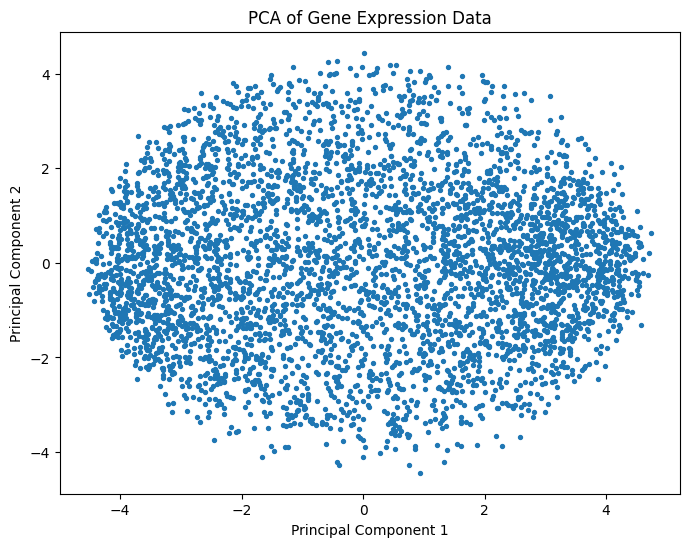

In [31]:
plt.figure(figsize=(8,6))

plt.scatter(X_pca[:,0], X_pca[:,1], s=8)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA of Gene Expression Data")

plt.show()

In [32]:
methods = ['single', 'complete', 'average', 'ward']

print("Cophenetic Correlation for Different Methods\n")

for method in methods:
    
    Z = linkage(X_scaled, method=method)

    c, _ = cophenet(Z, pdist(X_scaled))

    print(f"{method:10s} : {c:.4f}")

Cophenetic Correlation for Different Methods

single     : 0.0659
complete   : 0.4560
average    : 0.6179
ward       : 0.4894


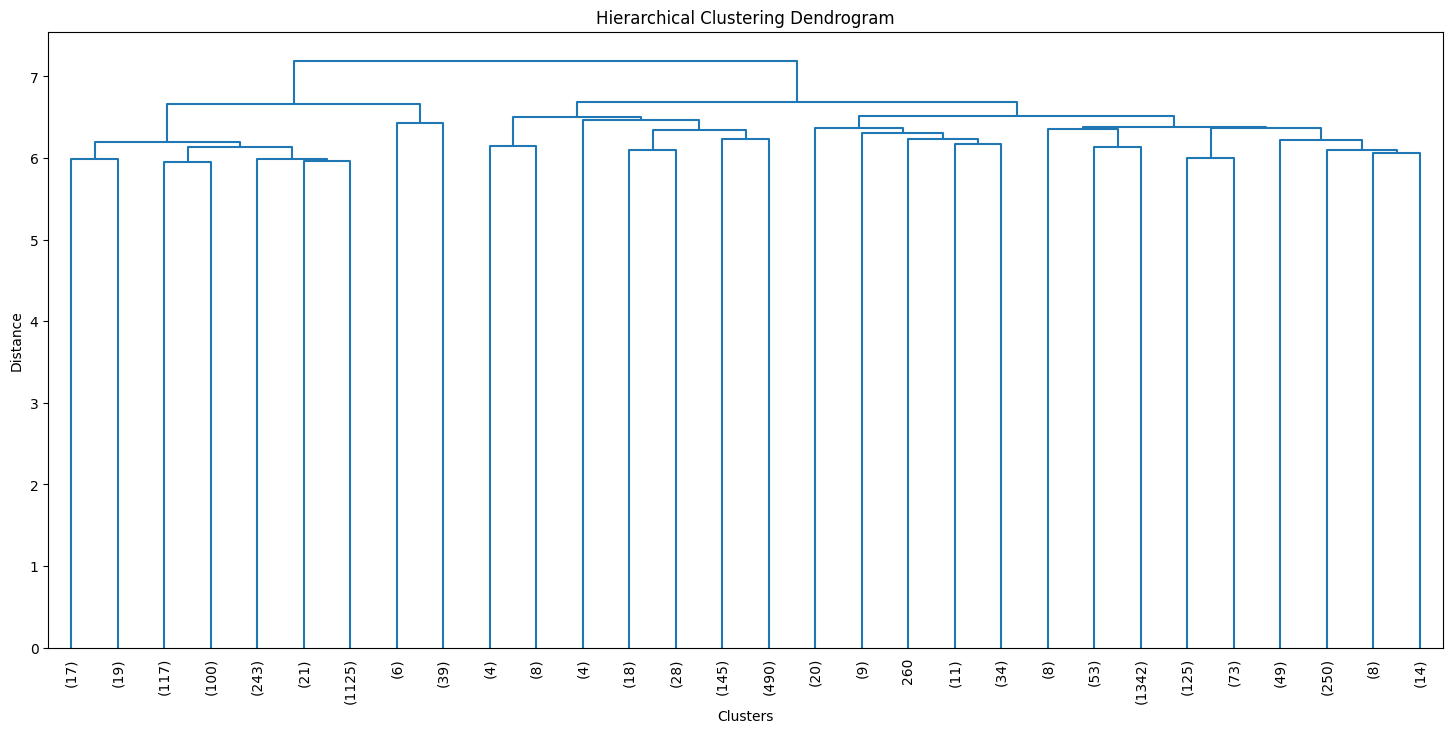

Cophenetic Correlation Coefficient: 0.6178645037879109


In [45]:
Z = linkage(X_scaled, method='average')
plt.figure(figsize=(18,8))

dendrogram(
    Z,
    truncate_mode='lastp',
    p=30,
    leaf_rotation=90,
    leaf_font_size=10
)

plt.title("Hierarchical Clustering Dendrogram")
plt.xlabel("Clusters")
plt.ylabel("Distance")

plt.show()
c, _ = cophenet(Z, pdist(X_scaled))

print("Cophenetic Correlation Coefficient:", c)

In [46]:
clusters = fcluster(Z, t=5, criterion='maxclust')
result = pd.DataFrame({
    'Gene': gene_names,
    'Cluster': clusters
})

result.head()

,Gene,Cluster
0,YAL001C,1
1,YAL014C,5
2,YAL016W,5
3,YAL020C,1
4,YAL022C,1


In [38]:
cluster_counts = result['Cluster'].value_counts().sort_index()

print("Genes in each cluster:")
print(cluster_counts)

Genes in each cluster:
Cluster
1    1642
2      45
3     697
4      75
5    1922
Name: count, dtype: int64


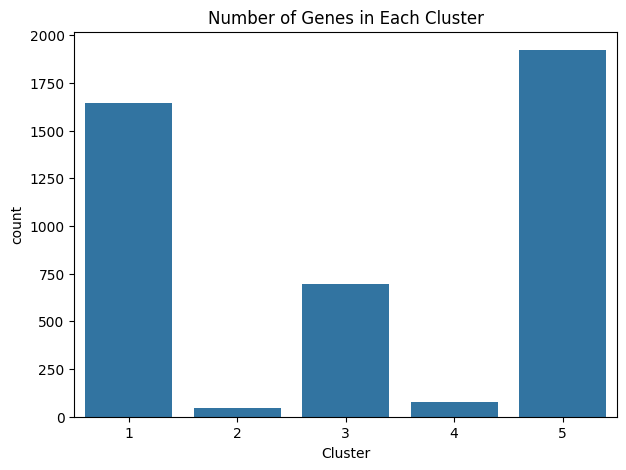

In [39]:
plt.figure(figsize=(7,5))

sns.countplot(x='Cluster', data=result)

plt.title("Number of Genes in Each Cluster")

plt.show()

In [40]:
for cluster in sorted(result['Cluster'].unique()):
    
    print("\nCluster", cluster)
    
    print(result[result['Cluster']==cluster]['Gene'].head(10))


Cluster 1
0       YAL001C
3       YAL020C
4       YAL022C
8       YAL040C
12      YAL049C
14      YAL056W
16    YAL064W-B
17      YAL065C
20      YAR020C
21      YAR035W
Name: Gene, dtype: str

Cluster 2
36     YBL031W
189    YBR262C
198    YBR279W
321    YCR029C
382    YCR093W
522    YDL213C
610    YDR073W
653    YDR121W
704    YDR177W
781    YDR266C
Name: Gene, dtype: str

Cluster 3
6     YAL038W
7     YAL039C
9     YAL044C
37    YBL033C
46    YBL075C
52    YBL099W
53    YBL101C
63    YBR038W
66    YBR056W
76    YBR082C
Name: Gene, dtype: str

Cluster 4
47       YBL077W
260      YCL051W
362      YCR070W
503    YDL134C-A
523      YDL214C
525      YDL216C
534      YDL232W
612      YDR075W
657      YDR126W
727      YDR201W
Name: Gene, dtype: str

Cluster 5
1     YAL014C
2     YAL016W
5     YAL036C
10    YAL046C
11    YAL048C
13    YAL051W
15    YAL063C
18    YAR007C
19    YAR009C
22    YAR043C
Name: Gene, dtype: str


In [41]:
result.to_csv("gene_clusters.csv", index=False)

In [42]:
cluster_profile = (
    pd.DataFrame(X)
    .assign(Cluster=clusters)
    .groupby("Cluster")
    .mean()
)

print(cluster_profile)

               40        50        60        70        80        90       100  \
Cluster                                                                         
1       -0.170435 -0.194610 -0.128511 -0.062412  0.218258 -0.166663  0.250639   
2        0.033222  0.038000  0.015444 -0.007111 -0.067556 -0.029778 -0.132444   
3       -0.322260 -0.390043 -0.339785 -0.289527 -0.301420 -0.122439 -0.153099   
4        0.072067  0.061200  0.068533  0.075867  0.055067  0.135200  0.430133   
5        0.275523  0.287680  0.237250  0.186821 -0.101353  0.111878 -0.110219   

              110       120       130  ...       170       180       190  \
Cluster                                ...                                 
1       -0.073551  0.181181 -0.142436  ... -0.023934  0.289495 -0.202521   
2       -0.023556  1.683111  0.032444  ... -0.027556 -0.161778 -0.123556   
3        0.068422 -0.105940  0.243917  ...  0.045610 -0.091349  0.019684   
4        0.112267 -0.136400  0.029333  ...  0.012933

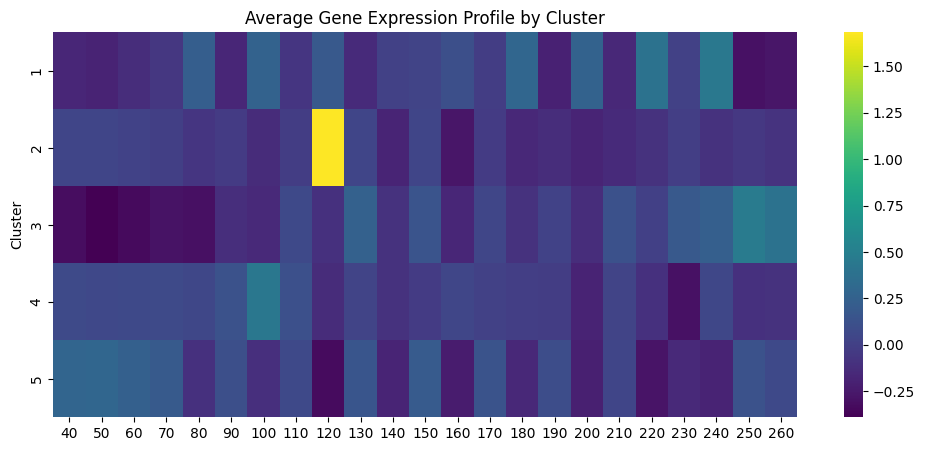

In [43]:
plt.figure(figsize=(12,5))
sns.heatmap(cluster_profile, cmap="viridis")
plt.title("Average Gene Expression Profile by Cluster")
plt.show()